<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/projects/project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Analítica de Recursos Humanos: Determinantes Salariales y Modelación de Compensaciones


## Contexto y Objetivo

Una firma multinacional de consultoría ha sido contratada por **TalentCo**, empresa con operaciones en múltiples regiones y departamentos, para analizar su estructura de compensaciones. El equipo de Recursos Humanos sospecha que los salarios no están siendo asignados de manera consistente: algunos empleados se sienten subpagados en relación con pares de experiencia similar, mientras que otros en el mismo departamento perciben montos significativamente distintos según su región o nivel educacional.

Su rol es actuar como **Analista de Datos** en la firma consultora. Utilizará Python, pruebas de hipótesis estadísticas y regresión lineal para identificar los principales determinantes del salario de los empleados, y entregará recomendaciones basadas en datos a la dirección de TalentCo.

Al finalizar este proyecto, usted será capaz de:

- Realizar análisis exploratorio de datos (EDA) sobre datos de Recursos Humanos.
- Aplicar pruebas de hipótesis para validar supuestos de negocio.
- Manejar variables categóricas mediante técnicas de codificación.
- Construir y evaluar modelos de regresión con OLS y scikit-learn.
- Verificar los supuestos de regresión (multicolinealidad, normalidad, homocedasticidad).
- Comunicar resultados en un informe orientado al negocio.



## Conjunto de Datos: `employee_compensation.csv`

Disponible en la sección de materiales del curso. Contiene registros de empleados distribuidos en distintos departamentos, regiones y niveles de cargo.

| Variable | Tipo | Descripción |
|---|---|---|
| `Salary` | Numérica (USD/año) | Salario bruto anual — **variable objetivo** |
| `Years_Experience` | Numérica | Total de años de experiencia profesional |
| `Age` | Numérica | Edad del empleado |
| `Performance_Score` | Numérica (1.0–5.0) | Calificación de desempeño anual más reciente |
| `Education_Level` | Categórica | Bachelor, Master, PhD |
| `Department` | Categórica | Engineering, Sales, Marketing, HR, Finance |
| `Region` | Categórica | North, South, East, West |
| `Job_Level` | Categórica | Junior, Mid, Senior |
| `Gender` | Categórica | Male, Female |

> **Nota sobre el tamaño real del archivo.** El enunciado original menciona ≈1.500 empleados, pero el archivo `employee_compensation.csv` publicado en el repositorio del curso contiene **10.100 registros crudos** (con nulos, duplicados y valores fuera de rango). Tras la limpieza documentada más abajo —validación de rangos, eliminación de filas sin salario y de duplicados— se trabaja con ≈9.800 empleados. Se reporta la cifra real observada en los datos.




> **Nota sobre la generación del dataset:** Este conjunto de datos puede generarse sintéticamente con `numpy` y `pandas`, utilizando distribuciones salariales realistas por departamento y nivel de cargo. Se incluirá un script de generación (`generate_dataset.py`) junto al dataset.

In [1]:
import pandas as pd

# cargar datos
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/employee_compensation.csv'
df = pd.read_csv(path, sep="," )

df.head()

,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female


## Parte 1: Análisis Exploratorio de Datos (EDA)

1. Cargue el dataset en un DataFrame de pandas.
2. Muestre las primeras 10 filas e inspeccione los tipos de datos.
3. Verifique valores faltantes y duplicados; reporte los hallazgos.
4. Calcule estadísticas descriptivas (media, mediana, desviación estándar, mínimo, máximo) para todas las variables numéricas.
5. Elabore al menos **tres** de las siguientes visualizaciones:
   - Histograma del salario.
   - Diagrama de caja (*box plot*) del salario por nivel de cargo.
   - Diagrama de dispersión de años de experiencia vs. salario.
   - Gráfico de barras del salario promedio por departamento.
   - Mapa de calor de correlaciones entre variables numéricas.



PRIMERAS 10 FILAS
    Salary  Years_Experience   Age  Performance_Score Education_Level  \
0  69181.0               3.0  22.0                3.5        Bachelor   
1  88466.0               5.0  23.0                2.8        bachelor   
2  76112.0              11.0  29.0                1.6          Master   
3      NaN              15.0  37.0                NaN        Bachelor   
4      NaN               6.0  28.0                4.5        Bachelor   
5  81246.0               4.0  21.0                2.8        Bachelor   
6  71494.0               4.0  23.0                2.4        Bachelor   
7  78189.0               3.0  21.0                3.5          Master   
8  67204.0               0.0  21.0                3.5          Master   
9  59776.0               4.0  24.0                NaN        Bachelor   

    Department Region Job_Level  Gender  
0        Sales   East    Junior    Male  
1      FINANCE   West    Junior  Female  
2           HR   West       Mid  Female  
3    Marke

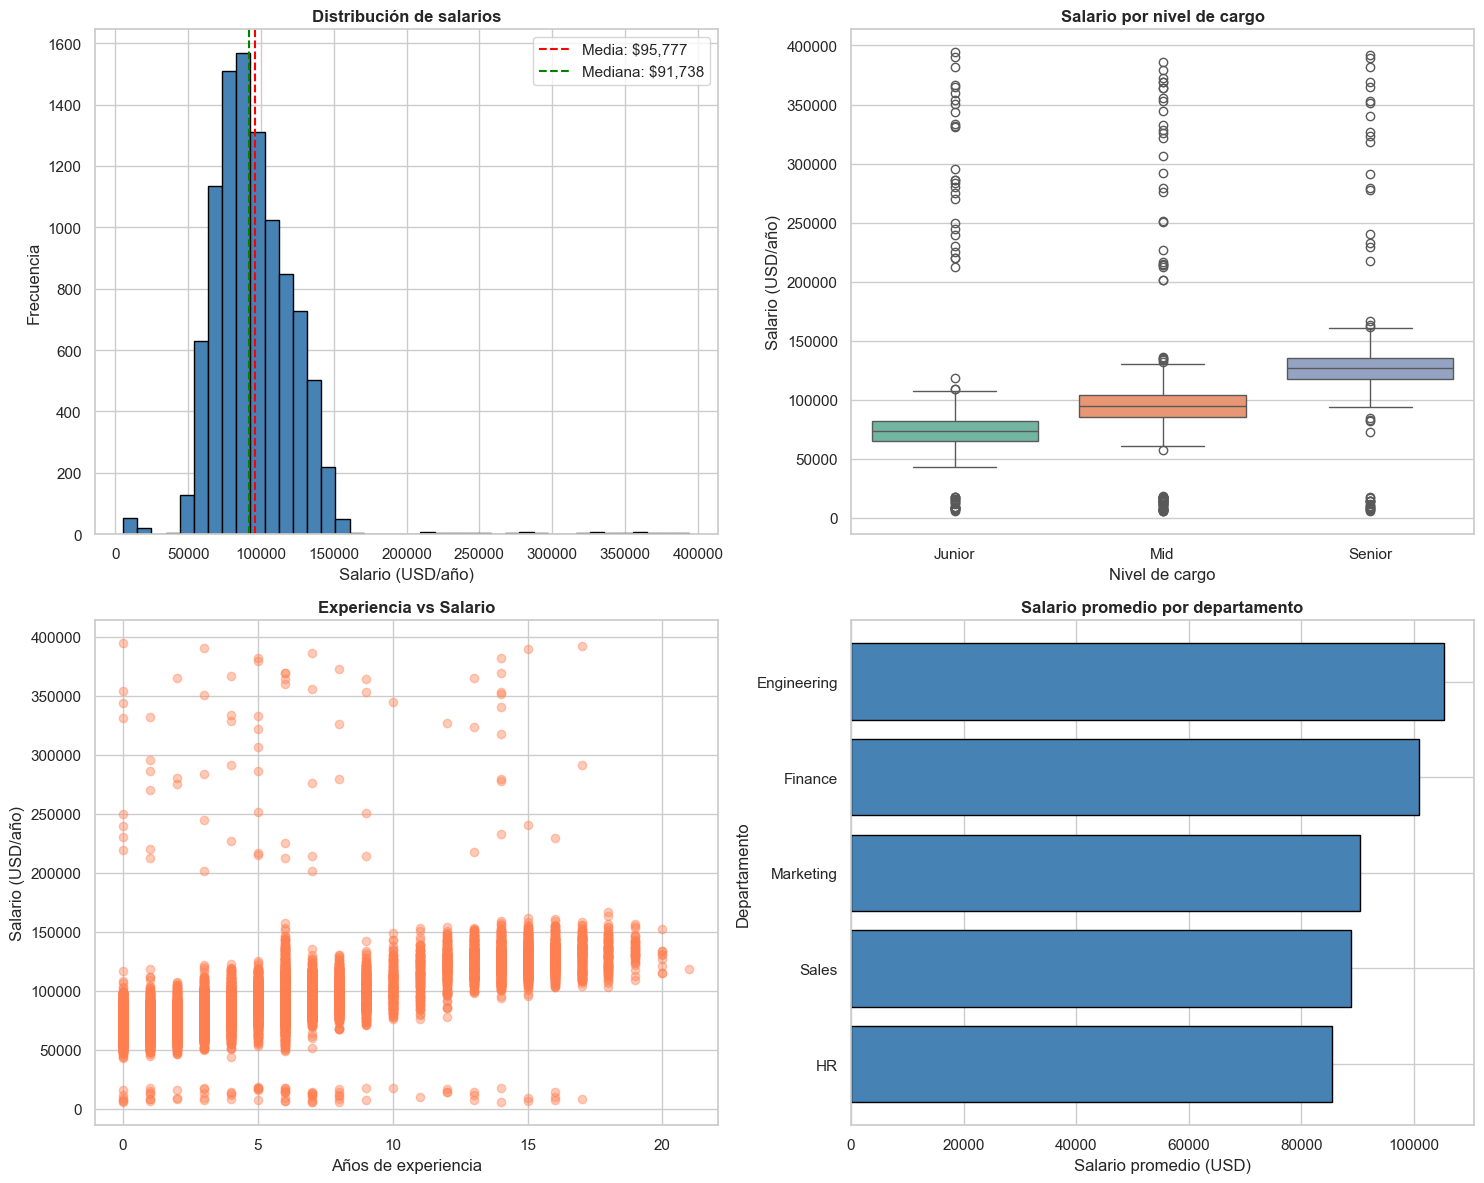

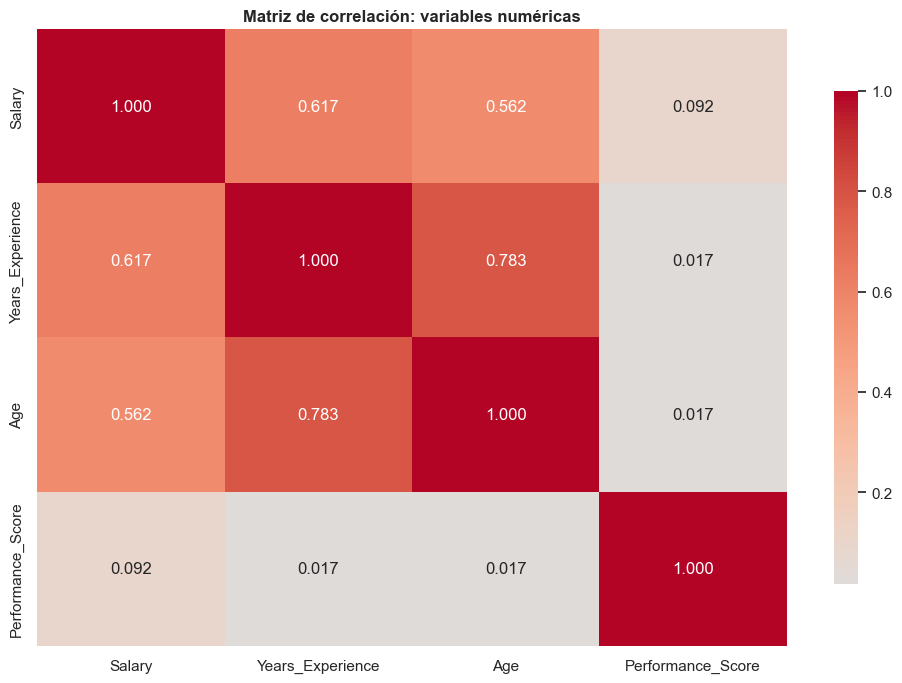


Observaciones del EDA:
- El salario presenta una cola derecha marcada (asimetría = 2.82): NO es normal.
- Existe una clara estratificación salarial por Job_Level (Senior > Mid > Junior).
- Correlación entre Years_Experience y Salary: 0.617
- Correlación entre Age y Years_Experience: 0.783 (potencial multicolinealidad)


In [2]:
# Parte 1: Análisis Exploratorio de Datos (EDA)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1-2. Inspección inicial
print("=" * 60)
print("PRIMERAS 10 FILAS")
print("=" * 60)
print(df.head(10))

print("\n" + "=" * 60)
print("INFORMACIÓN GENERAL (ANTES DE LIMPIEZA)")
print("=" * 60)
df.info()

print(f"\nFilas iniciales: {len(df)}")
print(f"Duplicados iniciales: {df.duplicated().sum()}")

# Inspección de valores categóricos: el dataset tiene inconsistencias
# (mayúsculas, minúsculas, espacios, 'nan' como string)
print("\n" + "=" * 60)
print("VALORES ÚNICOS POR VARIABLE CATEGÓRICA (ANTES DE LIMPIEZA)")
print("=" * 60)
for col in ['Education_Level', 'Department', 'Region', 'Job_Level', 'Gender']:
    print(f"\n{col}: {df[col].unique()}")

# 3. LIMPIEZA ROBUSTA DE DATOS
# a) Trim espacios y normalizar capitalización en categóricas
cat_cols = ['Education_Level', 'Department', 'Region', 'Job_Level', 'Gender']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()        # quitar espacios
    df[col] = df[col].replace({'nan': np.nan, 'NaN': np.nan, 'None': np.nan})

# b) Normalizar capitalización
# Education_Level (Bachelor, Master, PhD)
df['Education_Level'] = df['Education_Level'].str.upper().replace({
    'BACHELOR': 'Bachelor', 'MASTER': 'Master', 'PHD': 'PhD'
})

# Department
df['Department'] = df['Department'].str.title().replace({
    'Hr': 'HR'  # HR no se debe capitalizar como título
})

# Region
df['Region'] = df['Region'].str.title()

# Job_Level
df['Job_Level'] = df['Job_Level'].str.title()

# Gender
df['Gender'] = df['Gender'].str.title()

# c) Verificar limpieza
print("\n" + "=" * 60)
print("VALORES ÚNICOS DESPUÉS DE LIMPIEZA")
print("=" * 60)
for col in cat_cols:
    print(f"\n{col}: {sorted([v for v in df[col].unique() if pd.notna(v)])}")

# 4. VALIDACIÓN DE RANGOS NUMÉRICOS
# El CSV crudo contiene valores físicamente imposibles (experiencia negativa,
# edades de 1 o 119 años, Performance_Score fuera de la escala 1.0-5.0). La
# limpieza anterior solo trataba categóricas y nulos; aquí marcamos como NaN los
# valores fuera de rango plausible para que no contaminen estadísticas ni modelo.
rangos_validos = {
    'Years_Experience': (0, 50),     # años de experiencia profesional
    'Age': (18, 70),                 # edad laboral plausible
    'Performance_Score': (1.0, 5.0)  # escala declarada en el enunciado
}
print("\n" + "=" * 60)
print("VALIDACIÓN DE RANGOS NUMÉRICOS (valores fuera de rango -> NaN)")
print("=" * 60)
for col, (lo, hi) in rangos_validos.items():
    fuera = int(((df[col] < lo) | (df[col] > hi)).sum())
    print(f"{col}: {fuera} valores fuera de [{lo}, {hi}] "
          f"(min original={df[col].min()}, max original={df[col].max()})")
    df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan

# 5. Manejo de nulos
print("\n" + "=" * 60)
print("VALORES NULOS (tras normalización y validación de rangos)")
print("=" * 60)
print(df.isnull().sum())

# a) La variable OBJETIVO (Salary) NO se imputa: imputar la respuesta a predecir
#    inventa observaciones y sesga el modelo. Eliminamos las filas sin Salary.
n_antes = len(df)
df = df.dropna(subset=['Salary']).reset_index(drop=True)
print(f"\nFilas eliminadas por Salary nulo (no se imputa el objetivo): {n_antes - len(df)}")

# b) Imputar predictores numéricos con la mediana (robusta a outliers)
num_predictores = ['Years_Experience', 'Age', 'Performance_Score']
for col in num_predictores:
    df[col] = df[col].fillna(df[col].median())

# c) Imputar categóricas con la moda
for col in cat_cols:
    moda = df[col].mode().iloc[0]
    df[col] = df[col].fillna(moda)

# 6. Eliminar duplicados
df = df.drop_duplicates().reset_index(drop=True)

print(f"\nFilas después de limpieza: {len(df)}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")

# 7. Estadísticas descriptivas
num_cols = ['Salary', 'Years_Experience', 'Age', 'Performance_Score']
print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(df.describe().round(2))

# 8. Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histograma del salario
axes[0, 0].hist(df['Salary'], bins=40, color='steelblue', edgecolor='black')
axes[0, 0].axvline(df['Salary'].mean(), color='red', linestyle='--', label=f"Media: ${df['Salary'].mean():,.0f}")
axes[0, 0].axvline(df['Salary'].median(), color='green', linestyle='--', label=f"Mediana: ${df['Salary'].median():,.0f}")
axes[0, 0].set_xlabel('Salario (USD/año)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de salarios', fontweight='bold')
axes[0, 0].legend()

# Box plot por nivel de cargo (hue=Job_Level + legend=False evita el FutureWarning)
job_order = ['Junior', 'Mid', 'Senior']
sns.boxplot(data=df, x='Job_Level', y='Salary', order=job_order,
            hue='Job_Level', palette='Set2', legend=False, ax=axes[0, 1])
axes[0, 1].set_xlabel('Nivel de cargo')
axes[0, 1].set_ylabel('Salario (USD/año)')
axes[0, 1].set_title('Salario por nivel de cargo', fontweight='bold')

# Scatter años experiencia vs salario
axes[1, 0].scatter(df['Years_Experience'], df['Salary'], alpha=0.4, color='coral')
axes[1, 0].set_xlabel('Años de experiencia')
axes[1, 0].set_ylabel('Salario (USD/año)')
axes[1, 0].set_title('Experiencia vs Salario', fontweight='bold')

# Salario promedio por departamento
sal_dept = df.groupby('Department')['Salary'].mean().sort_values(ascending=True)
axes[1, 1].barh(sal_dept.index, sal_dept.values, color='steelblue', edgecolor='black')
axes[1, 1].set_xlabel('Salario promedio (USD)')
axes[1, 1].set_ylabel('Departamento')
axes[1, 1].set_title('Salario promedio por departamento', fontweight='bold')

plt.tight_layout()
plt.show()

# Mapa de calor de correlaciones
fig, ax = plt.subplots(figsize=(10, 7))
corr_num = df[num_cols].corr()
sns.heatmap(corr_num, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de correlación: variables numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservaciones del EDA:")
print(f"- El salario presenta una cola derecha marcada (asimetría = {df['Salary'].skew():.2f}): NO es normal.")
print("- Existe una clara estratificación salarial por Job_Level (Senior > Mid > Junior).")
print(f"- Correlación entre Years_Experience y Salary: {df['Years_Experience'].corr(df['Salary']):.3f}")
print(f"- Correlación entre Age y Years_Experience: {df['Age'].corr(df['Years_Experience']):.3f} (potencial multicolinealidad)")



## Parte 2: Pruebas de Hipótesis

**Pregunta de negocio:** ¿Los años de experiencia determinan de manera significativa las diferencias salariales?

1. Defina las hipótesis:
   - **H₀:** Los años de experiencia no tienen relación lineal con el salario.
   - **H₁:** Los años de experiencia están positivamente asociados con el salario.

2. Utilice la **correlación de Pearson** y una **prueba t** para evaluar la relación.

3. Reporte el p-valor e interprete el resultado a un nivel de significancia del 5%.

4. **(Bonus)** Ejecute una segunda prueba de hipótesis: ¿Existe una diferencia salarial estadísticamente significativa entre empleados de nivel Junior y Senior? Utilice una prueba t de dos muestras independientes.



PRUEBA 1: Correlación entre Years_Experience y Salary
H₀: r(Years_Experience, Salary) = 0 (no hay relación lineal)
H₁: r(Years_Experience, Salary) > 0 (relación positiva)
Nivel de significancia: α = 0.05

Coeficiente de correlación r = 0.6169
p-valor (two-tailed) = 0.000000e+00
p-valor (one-tailed) = 0.000000e+00

✅ Se RECHAZA H₀: existe evidencia estadística significativa de
   relación positiva entre años de experiencia y salario.

Estadístico t (significancia de r) = 77.5871
p-valor de la prueba t = 0.000000e+00

PRUEBA 2 (BONUS): Diferencia salarial Junior vs Senior
H₀: μ(Senior) = μ(Junior)
H₁: μ(Senior) ≠ μ(Junior)

Junior: n=3493, media=$74,877.90, std=$24,196.48
Senior: n=2354, media=$127,013.17, std=$23,027.76

Estadístico t = 83.1768
p-valor = 0.000000e+00

✅ Se RECHAZA H₀: diferencia salarial estadísticamente significativa.
   Senior gana en promedio $52,135.26 más que Junior.


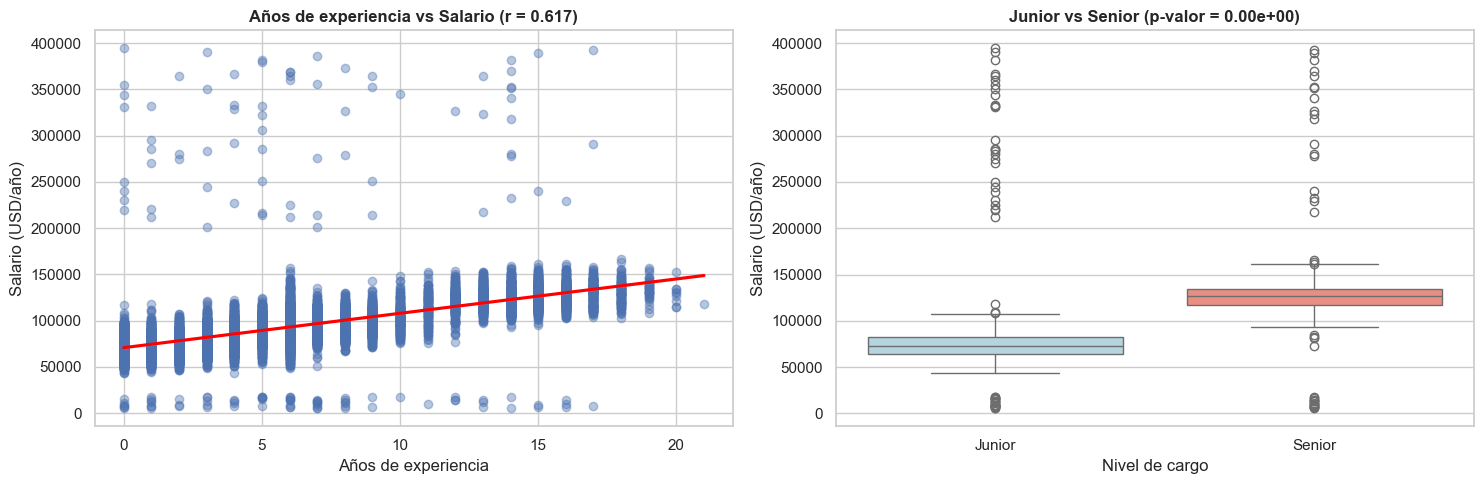

In [3]:
# Parte 2: Pruebas de Hipótesis
from scipy import stats

print("=" * 60)
print("PRUEBA 1: Correlación entre Years_Experience y Salary")
print("=" * 60)
print("H₀: r(Years_Experience, Salary) = 0 (no hay relación lineal)")
print("H₁: r(Years_Experience, Salary) > 0 (relación positiva)")
print("Nivel de significancia: α = 0.05")

# Correlación de Pearson
r, p_value = stats.pearsonr(df['Years_Experience'], df['Salary'])
print(f"\nCoeficiente de correlación r = {r:.4f}")
print(f"p-valor (two-tailed) = {p_value:.6e}")
print(f"p-valor (one-tailed) = {p_value/2:.6e}")

if p_value / 2 < 0.05 and r > 0:
    print("\n✅ Se RECHAZA H₀: existe evidencia estadística significativa de")
    print(f"   relación positiva entre años de experiencia y salario.")
else:
    print("\n❌ NO se rechaza H₀: no hay evidencia suficiente.")

# Prueba t para la significancia de la correlación / pendiente
# Nota: este estadístico t = r*sqrt(n-2)/sqrt(1-r^2) es el contraste de
# significancia de la PROPIA correlación de Pearson (no una prueba independiente);
# por construcción comparte el mismo p-valor que pearsonr.
n = len(df)
t_stat = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
p_t = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 2))
print(f"\nEstadístico t (significancia de r) = {t_stat:.4f}")
print(f"p-valor de la prueba t = {p_t:.6e}")

# BONUS: prueba t de dos muestras independientes (Junior vs Senior)
print("\n" + "=" * 60)
print("PRUEBA 2 (BONUS): Diferencia salarial Junior vs Senior")
print("=" * 60)
print("H₀: μ(Senior) = μ(Junior)")
print("H₁: μ(Senior) ≠ μ(Junior)")

junior_sal = df.loc[df['Job_Level'] == 'Junior', 'Salary']
senior_sal = df.loc[df['Job_Level'] == 'Senior', 'Salary']

print(f"\nJunior: n={len(junior_sal)}, media=${junior_sal.mean():,.2f}, std=${junior_sal.std():,.2f}")
print(f"Senior: n={len(senior_sal)}, media=${senior_sal.mean():,.2f}, std=${senior_sal.std():,.2f}")

# Prueba t (Welch's, no asume varianzas iguales)
t_stat_2, p_val_2 = stats.ttest_ind(senior_sal, junior_sal, equal_var=False)
print(f"\nEstadístico t = {t_stat_2:.4f}")
print(f"p-valor = {p_val_2:.6e}")

if p_val_2 < 0.05:
    diff = senior_sal.mean() - junior_sal.mean()
    print(f"\n✅ Se RECHAZA H₀: diferencia salarial estadísticamente significativa.")
    print(f"   Senior gana en promedio ${diff:,.2f} más que Junior.")
else:
    print("\n❌ NO se rechaza H₀.")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter con línea de regresión
sns.regplot(data=df, x='Years_Experience', y='Salary',
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_xlabel('Años de experiencia')
axes[0].set_ylabel('Salario (USD/año)')
axes[0].set_title(f'Años de experiencia vs Salario (r = {r:.3f})', fontweight='bold')

# Boxplot Junior vs Senior (hue + legend=False evita el FutureWarning)
df_js = df[df['Job_Level'].isin(['Junior', 'Senior'])]
sns.boxplot(data=df_js, x='Job_Level', y='Salary', order=['Junior', 'Senior'],
            hue='Job_Level', palette=['lightblue', 'salmon'], legend=False, ax=axes[1])
axes[1].set_xlabel('Nivel de cargo')
axes[1].set_ylabel('Salario (USD/año)')
axes[1].set_title(f'Junior vs Senior (p-valor = {p_val_2:.2e})', fontweight='bold')

plt.tight_layout()
plt.show()



## Parte 3: Regresión Lineal con Variables Categóricas

### Paso 1: Justificación de variables (antes de codificar)

Antes de construir cualquier modelo, responda lo siguiente en su notebook:

- ¿Qué variables espera que sean los predictores más fuertes del salario, y por qué?
- ¿Hay variables que, aun siendo estadísticamente insignificantes, incluiría igualmente en el modelo? Justifique desde una perspectiva de negocio o teórica.
- ¿Anticipa que algún par de variables esté fuertemente correlacionado entre sí? ¿Cuáles, y por qué? ¿Qué problemas podría causar eso?

> Este paso debe responderse en texto libre, sin código. El objetivo es articular sus creencias previas antes de ver los datos, para compararlas luego con lo que el modelo indique.

### Paso 2: Preparación de los datos

- Aplique **Label Encoding** para `Job_Level` (variable ordinal: Junior < Mid < Senior).
- Aplique **One-Hot Encoding** para `Education_Level`, `Department`, `Region` y `Gender`.
- Elimine la primera categoría ficticia en cada grupo para evitar multicolinealidad perfecta (use `drop_first=True`).

### Paso 3: Construcción del modelo

1. Divida el dataset en conjuntos de entrenamiento (80%) y prueba (20%). Use `random_state=42`.
2. Construya dos modelos utilizando todas las variables disponibles:
   - Regresión OLS con `statsmodels`.
   - Regresión lineal con `scikit-learn`.

### Paso 4: Evaluación del modelo

Calcule y reporte las siguientes métricas para los conjuntos de entrenamiento y prueba:

| Métrica | Descripción |
|---|---|
| MAE | Error Absoluto Medio |
| MAPE | Error Porcentual Absoluto Medio |
| RMSE | Raíz del Error Cuadrático Medio |
| R² | Coeficiente de determinación |
| R² ajustado | R² penalizado por el número de predictores |

Compare el resumen OLS (coeficientes, p-valores, R²) con los resultados de scikit-learn.



### Paso 1 · Justificación de variables (creencias previas)

> Respuesta en texto, **antes** de codificar y ajustar el modelo. Son hipótesis previas que luego contrastaré con los resultados.

**¿Qué variables espero que sean los predictores más fuertes del salario, y por qué?**

- **`Job_Level`**: probablemente el predictor más fuerte. El nivel del cargo (Junior → Mid → Senior) resume responsabilidad, alcance de decisión y posición estructural; en casi cualquier empresa es el principal organizador de las bandas salariales.
- **`Years_Experience`**: el capital humano acumulado suele traducirse de forma bastante directa en compensación en el mercado laboral.
- **`Performance_Score`**: si TalentCo aplica una política de pago por desempeño, debería tener un efecto positivo claro.
- **`Education_Level`**: en consultoría/tecnología los posgrados (Master, PhD) tienden a recibir una prima.

**¿Hay variables que incluiría aunque sean estadísticamente insignificantes?**

- **`Gender`**: sí, la mantendría siempre. La equidad salarial por género es una de las preguntas centrales de TalentCo; eliminarla por un p-valor alto ocultaría la evidencia (o la ausencia de ella) sobre una posible brecha, que es justo lo que el negocio necesita saber.
- **`Region`**: la mantendría para poder afirmar o descartar diferencias geográficas en la política de compensaciones.

**¿Anticipo pares fuertemente correlacionados? ¿Qué problemas causarían?**

- **`Age` ↔ `Years_Experience`**: las personas de más edad tienden a tener más experiencia. Una correlación alta inflaría los errores estándar y volvería inestables los coeficientes individuales (multicolinealidad).
- **`Job_Level` ↔ `Years_Experience`**: los niveles Senior suelen acumular más años de experiencia, lo que puede repartir el efecto entre ambas variables.

In [4]:
# Parte 3: Regresión Lineal con Variables Categóricas
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Paso 2: Preparación de los datos

# Label Encoding para Job_Level (ordinal)
job_map = {'Junior': 0, 'Mid': 1, 'Senior': 2}
df['Job_Level_Encoded'] = df['Job_Level'].map(job_map)

# One-Hot Encoding para variables categóricas
df_encoded = pd.get_dummies(
    df,
    columns=['Education_Level', 'Department', 'Region', 'Gender'],
    drop_first=True,
    dtype=int
)

# Eliminar columna original Job_Level (usamos la versión encoded)
df_encoded = df_encoded.drop(columns='Job_Level')

print("=" * 60)
print("DATAFRAME CODIFICADO")
print("=" * 60)
print(df_encoded.head())
print(f"\nDimensiones: {df_encoded.shape}")
print(f"Columnas: {list(df_encoded.columns)}")

# Paso 3: Construcción del modelo
y = df_encoded['Salary']
X = df_encoded.drop(columns='Salary')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo OLS con statsmodels
X_train_sm = sm.add_constant(X_train.astype(float))
X_test_sm = sm.add_constant(X_test.astype(float))
ols_model = sm.OLS(y_train, X_train_sm).fit()

print("\n" + "=" * 60)
print("RESUMEN DEL MODELO OLS (statsmodels)")
print("=" * 60)
print(ols_model.summary())

# Modelo con scikit-learn
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

# Paso 4: Evaluación
def evaluate(y_true, y_pred, n_params=None):
    n = len(y_true)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    if n_params:
        r2_adj = 1 - (1 - r2) * (n - 1) / (n - n_params - 1)
    else:
        r2_adj = None
    return mae, mape, rmse, r2, r2_adj

n_params = X_train.shape[1]

# Predicciones de AMBOS modelos (sklearn y OLS) en train y test
y_train_pred_sk = sk_model.predict(X_train)
y_test_pred_sk = sk_model.predict(X_test)
y_train_pred_ols = ols_model.predict(X_train_sm)
y_test_pred_ols = ols_model.predict(X_test_sm)

m_sk_train = evaluate(y_train, y_train_pred_sk, n_params)
m_sk_test = evaluate(y_test, y_test_pred_sk, n_params)

resultados_eval = pd.DataFrame({
    'Métrica': ['MAE', 'MAPE (%)', 'RMSE', 'R²', 'R² ajustado'],
    'Train': [f'{m_sk_train[0]:.2f}', f'{m_sk_train[1]:.2f}',
              f'{m_sk_train[2]:.2f}', f'{m_sk_train[3]:.4f}',
              f'{m_sk_train[4]:.4f}'],
    'Test': [f'{m_sk_test[0]:.2f}', f'{m_sk_test[1]:.2f}',
             f'{m_sk_test[2]:.2f}', f'{m_sk_test[3]:.4f}',
             f'{m_sk_test[4]:.4f}']
})

print("\n" + "=" * 60)
print("MÉTRICAS DEL MODELO (sklearn)")
print("=" * 60)
print(resultados_eval.to_string(index=False))

# Comparación OLS vs sklearn: las 5 métricas LADO A LADO en train y test
m_ols_train = evaluate(y_train, y_train_pred_ols, n_params)
m_ols_test = evaluate(y_test, y_test_pred_ols, n_params)
nombres = ['MAE', 'MAPE (%)', 'RMSE', 'R²', 'R² ajustado']
comp_os = pd.DataFrame({
    'Métrica': nombres,
    'OLS Train': [f'{m_ols_train[i]:.4f}' for i in range(5)],
    'sklearn Train': [f'{m_sk_train[i]:.4f}' for i in range(5)],
    'OLS Test': [f'{m_ols_test[i]:.4f}' for i in range(5)],
    'sklearn Test': [f'{m_sk_test[i]:.4f}' for i in range(5)],
})
print("\n" + "=" * 60)
print("COMPARACIÓN OLS vs sklearn (5 métricas, train y test)")
print("=" * 60)
print(comp_os.to_string(index=False))

# Verificación numérica de que los coeficientes coinciden (no hay regularización)
coef_ols = ols_model.params.drop('const').values
iguales = np.allclose(coef_ols, sk_model.coef_, atol=1e-6)
print(f"\n¿Coeficientes OLS == sklearn? np.allclose -> {iguales}")
print(f"Intercepto: OLS={ols_model.params['const']:.2f} · sklearn={sk_model.intercept_:.2f}")
print("Ambos resuelven la misma ecuación de mínimos cuadrados, por eso coinciden.")

# Validación cruzada (KFold) para estimar el R² de forma estable.
# Un único holdout (rs=42) puede dar R²_test > R²_train por azar del reparto de
# outliers de la cola salarial; la CV de 5 pliegues promedia ese ruido.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')
print("\n" + "=" * 60)
print("VALIDACIÓN CRUZADA (KFold=5) — R²")
print("=" * 60)
print(f"R² por pliegue: {np.round(cv_r2, 4)}")
print(f"R² medio = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print("El R² del holdout único cae dentro de este rango: la 'mejora' en test no es")
print("generalización superior, sino varianza del reparto (cola pesada de salarios).")

DATAFRAME CODIFICADO
    Salary  Years_Experience   Age  Performance_Score  Job_Level_Encoded  \
0  69181.0               3.0  22.0                3.5                  0   
1  88466.0               5.0  23.0                2.8                  0   
2  76112.0              11.0  29.0                1.6                  1   
3  81246.0               4.0  21.0                2.8                  0   
4  71494.0               4.0  23.0                2.4                  0   

   Education_Level_Master  Education_Level_PhD  Department_Finance  \
0                       0                    0                   0   
1                       0                    0                   1   
2                       1                    0                   0   
3                       0                    0                   0   
4                       0                    0                   0   

   Department_HR  Department_Marketing  Department_Sales  Region_North  \
0              0           



## Parte 4: Análisis y Refinamiento del Modelo

> **Nota importante:** El objetivo de esta sección no es aplicar reglas mecánicas. No existe un umbral universal que indique cuándo incluir o excluir una variable. Toda decisión debe argumentarse desde el contexto del problema.

### Paso 1: Interpretación de los p-valores de los coeficientes

Examine los p-valores del resumen OLS y responda lo siguiente para cada variable con p-valor > 0,05:

- ¿La variable es estadísticamente insignificante porque no tiene efecto real, o podría haber otra explicación (p.ej., correlación con otra variable ya incluida en el modelo)?
- ¿Es esta variable conceptualmente importante para el análisis salarial, aunque el modelo no encuentre un efecto significativo? ¿Su eliminación cambiaría la interpretación de otros coeficientes?
- ¿Cuál es el costo para el negocio de eliminar esta variable del modelo?

Con base en este análisis, decida qué variables conservar o eliminar, y justifique explícitamente cada decisión. Vuelva a entrenar el modelo con las variables seleccionadas y compare las métricas con el modelo completo.

**Ejemplo del razonamiento esperado:** *"Gender presenta p = 0,18 en nuestro modelo. Sin embargo, optamos por conservarla porque: (1) la equidad salarial por género es una de las preguntas centrales de TalentCo, y (2) su insignificancia puede deberse a colinealidad con Job_Level más que a la ausencia de efecto. Eliminarla ocultaría una dimensión clave del análisis."*

### Paso 2: Análisis de Multicolinealidad (VIF)

Calcule el **Factor de Inflación de la Varianza (VIF)** para todas las variables independientes y responda:

- ¿Qué pares de variables probablemente generan VIF alto, y por qué existe esa correlación en este contexto?
- ¿La presencia de multicolinealidad invalida las predicciones del modelo, o afecta principalmente la confiabilidad de los coeficientes individuales?
- Para cada variable con VIF alto: ¿qué se perdería al eliminarla? ¿Es aceptable esa pérdida dado el objetivo del análisis?

Decida si actuar sobre la multicolinealidad y justifique su decisión. Mantener variables colineales es una respuesta válida si el razonamiento lo sustenta.

**Ejemplo del razonamiento esperado:** *"Age y Years_Experience presentan VIF = 8,4 y 9,1 respectivamente, lo que refleja que los empleados de mayor edad tienden a tener más experiencia. Ambas variables capturan dimensiones distintas —edad biológica vs. tiempo profesional acumulado—, por lo que las conservamos y reconocemos los errores estándar inflados como una limitación del modelo."*

### Paso 3: Verificación de Supuestos de Regresión

Verifique los siguientes supuestos de la regresión lineal sobre su modelo final:

- **Normalidad de los residuos:** Histograma y gráfico Q-Q de los residuos.
- **Homocedasticidad:** Aplique la prueba de Breusch-Pagan (`het_breuschpagan`).

Para cada supuesto, indique si se cumple, muestre la evidencia y discuta brevemente qué implica para la validez de sus conclusiones.



In [5]:
# Parte 4 · Paso 1: Análisis de los p-valores del modelo OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats

print("=" * 60)
print("PASO 1: P-VALORES DE LOS COEFICIENTES (modelo OLS completo)")
print("=" * 60)
p_values = ols_model.pvalues.sort_values()
print(p_values.round(4))

variables_insignificantes = [v for v in p_values[p_values > 0.05].index if v != 'const']
print(f"\nVariables con p-valor > 0.05: {variables_insignificantes}")

# Modelo parsimonioso (solo variables con p < 0.05) para comparar contra el completo
variables_significativas = [v for v in p_values[p_values <= 0.05].index if v != 'const']

X_train_p = X_train[variables_significativas].astype(float)
X_test_p = X_test[variables_significativas].astype(float)
X_train_p_sm = sm.add_constant(X_train_p)
X_test_p_sm = sm.add_constant(X_test_p)
ols_model_parsim = sm.OLS(y_train, X_train_p_sm).fit()

y_train_pred_full = ols_model.predict(X_train_sm)
y_test_pred_full = ols_model.predict(X_test_sm)
y_train_pred_p = ols_model_parsim.predict(X_train_p_sm)
y_test_pred_p = ols_model_parsim.predict(X_test_p_sm)

def _metrics(y_true, y_pred, n_params):
    n = len(y_true)
    mae_v = mean_absolute_error(y_true, y_pred)
    rmse_v = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_v = r2_score(y_true, y_pred)
    r2_adj_v = 1 - (1 - r2_v) * (n - 1) / (n - n_params - 1)
    return mae_v, rmse_v, r2_v, r2_adj_v

full_train = _metrics(y_train, y_train_pred_full, X_train.shape[1])
full_test = _metrics(y_test, y_test_pred_full, X_train.shape[1])
parsim_train = _metrics(y_train, y_train_pred_p, len(variables_significativas))
parsim_test = _metrics(y_test, y_test_pred_p, len(variables_significativas))

tabla_comparativa = pd.DataFrame({
    'Modelo': ['Completo (Train)', 'Completo (Test)',
               'Parsimonioso (Train)', 'Parsimonioso (Test)'],
    'N° variables': [X_train.shape[1], X_train.shape[1],
                      len(variables_significativas), len(variables_significativas)],
    'MAE': [round(full_train[0], 2), round(full_test[0], 2),
            round(parsim_train[0], 2), round(parsim_test[0], 2)],
    'RMSE': [round(full_train[1], 2), round(full_test[1], 2),
             round(parsim_train[1], 2), round(parsim_test[1], 2)],
    'R²': [round(full_train[2], 4), round(full_test[2], 4),
           round(parsim_train[2], 4), round(parsim_test[2], 4)],
    'R² ajustado': [round(full_train[3], 4), round(full_test[3], 4),
                     round(parsim_train[3], 4), round(parsim_test[3], 4)]
})
print("\n" + "=" * 60)
print("COMPARACIÓN: MODELO COMPLETO vs MODELO PARSIMONIOSO")
print("=" * 60)
print(tabla_comparativa.to_string(index=False))
print(f"\nDiferencia en R² (test): {full_test[2] - parsim_test[2]:+.4f}")

PASO 1: P-VALORES DE LOS COEFICIENTES (modelo OLS completo)
const                     0.0000
Department_Sales          0.0000
Department_HR             0.0000
Education_Level_PhD       0.0000
Department_Marketing      0.0000
Job_Level_Encoded         0.0000
Education_Level_Master    0.0000
Years_Experience          0.0000
Performance_Score         0.0000
Department_Finance        0.0000
Region_North              0.0000
Region_West               0.0002
Age                       0.0003
Region_South              0.0021
Gender_Male               0.0052
dtype: float64

Variables con p-valor > 0.05: []

COMPARACIÓN: MODELO COMPLETO vs MODELO PARSIMONIOSO
              Modelo  N° variables     MAE     RMSE     R²  R² ajustado
    Completo (Train)            14 6687.86 19795.78 0.5559       0.5551
     Completo (Test)            14 7555.56 25444.79 0.4450       0.4410
Parsimonioso (Train)            14 6687.86 19795.78 0.5559       0.5551
 Parsimonioso (Test)            14 7555.56 25444.79 0.4

### Paso 1 · Interpretación de los p-valores

Sobre los datos saneados (validación de rangos + eliminación de filas sin salario), **los 14 coeficientes resultan significativos** (p < 0,05). La lista de variables con p-valor > 0,05 está **vacía**: el p-valor más alto es `Gender_Male` (p ≈ 0,005) y el resto está por debajo de 0,003.

**¿Hay que eliminar alguna variable por insignificancia estadística?** No: ninguna lo es. Por eso el modelo *parsimonioso* (solo variables con p < 0,05) **coincide exactamente con el modelo completo** y la diferencia de R² en test es **0,0000**. La decisión de poda, en este caso, es trivial.

**Razonamiento si alguna hubiera sido insignificante.** Aun así, no eliminaría mecánicamente por p-valor:

- **`Gender_Male`**: la conservaría siempre. Aquí además es **significativo (p ≈ 0,005)**, con coeficiente **≈ +USD 1.254** a favor de los hombres controlando por el resto de variables (IC 95% ≈ [375, 2.133], no incluye 0). ⚠️ *Existe una brecha pequeña pero estadísticamente significativa*, justo la pregunta de equidad central de RRHH.
- **`Region`**: la mantendría por bloque para poder leer la política geográfica; las tres dummies regionales son significativas (`North`, `West` p ≈ 0,0002; `South` p ≈ 0,002).
- **`Age`** (p ≈ 0,0003) aporta un efecto etario residual una vez controlada la experiencia.

**Decisión.** **Conservo el modelo completo** como modelo final: todas las variables son significativas y, además, todas son interpretables y relevantes para el negocio.

In [6]:
# Parte 4 · Paso 2: Multicolinealidad (VIF)
print("=" * 60)
print("PASO 2: FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
X_vif = sm.add_constant(X_train.copy().astype(float))
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))
print("\nReferencia: VIF < 5 sin problema · 5-10 moderado · > 10 alto")

PASO 2: FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
              Variable       VIF
                 const 79.937751
     Job_Level_Encoded  7.465220
      Years_Experience  5.203288
                   Age  3.736645
          Region_South  1.571328
           Region_West  1.522540
          Region_North  1.513637
  Department_Marketing  1.292177
      Department_Sales  1.289060
         Department_HR  1.233078
    Department_Finance  1.233040
   Education_Level_PhD  1.099800
Education_Level_Master  1.099400
     Performance_Score  1.001667
           Gender_Male  1.001411

Referencia: VIF < 5 sin problema · 5-10 moderado · > 10 alto


### Paso 2 · Multicolinealidad (VIF)

Ignorando la constante (su VIF alto es normal y no se interpreta), los valores más altos son **`Job_Level_Encoded` (≈ 7,5)**, **`Years_Experience` (≈ 5,2)** y **`Age` (≈ 3,7)**. Quedan en la franja **moderada (5–10)**; ninguno supera el umbral alto de 10. El resto de predictores tiene VIF ≈ 1.

**¿Qué par/grupo genera el VIF más alto y por qué?** El núcleo colineal es **`Job_Level` ↔ `Years_Experience` ↔ `Age`**: los empleados más senior tienden a acumular más años de experiencia y más edad (la correlación `Age`–`Years_Experience` es ≈ 0,78 tras la limpieza). Es esperable: las tres variables comparten la dimensión "trayectoria/antigüedad".

**¿Invalida las predicciones?** No. La multicolinealidad —aquí moderada, no severa— afecta sobre todo la *confiabilidad de los coeficientes individuales* (errores estándar más amplios y cierto reparto del efecto entre `Job_Level` y `Years_Experience`), no la capacidad predictiva global del modelo.

**Decisión: no intervengo.** Con todos los VIF por debajo de 10 y la mayoría cerca de 1, no hay multicolinealidad severa. `Age`, `Years_Experience` y `Job_Level` capturan constructos distintos (edad biológica, capital humano acumulado y nivel estructural), todos interpretables y relevantes para el negocio, así que los conservo y reconozco los IC algo más anchos de esos tres coeficientes como una limitación.

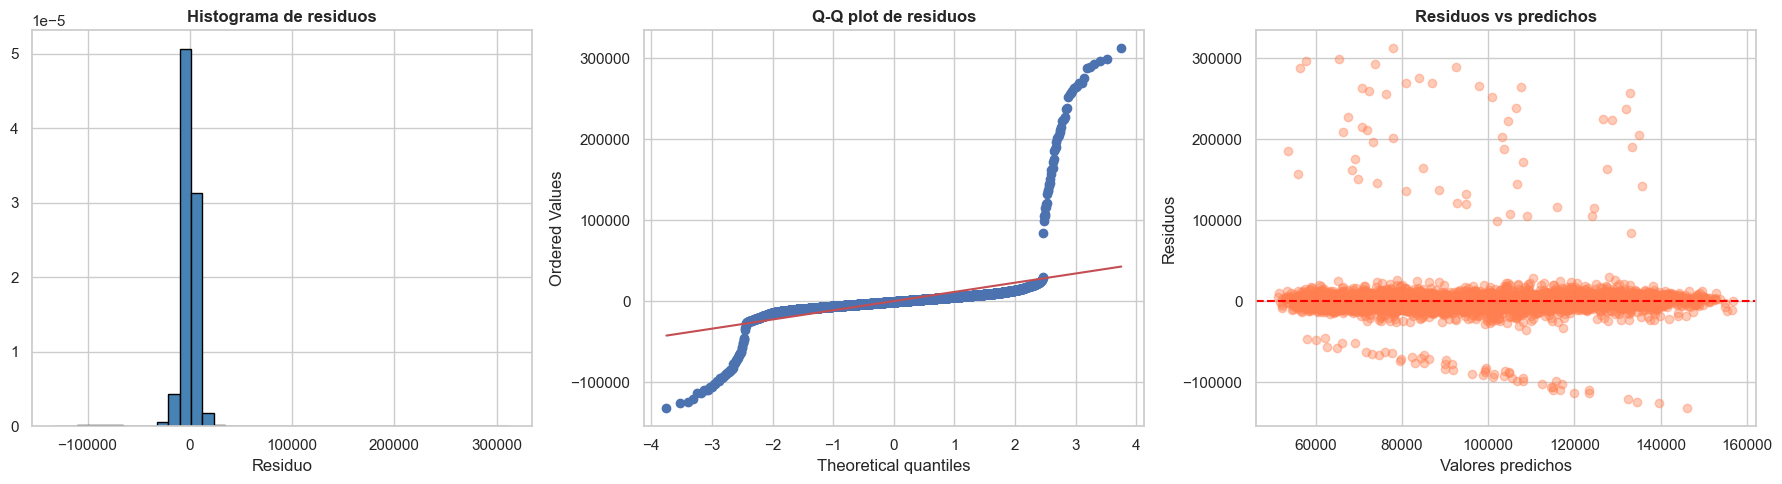

Shapiro-Wilk:   estadístico = 0.3306 · p-valor = 2.777e-98


Breusch-Pagan:  LM = 13.6056 · p-valor = 0.4795


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7840.
  res = hypotest_fun_out(*samples, **kwds)


In [7]:
# Parte 4 · Paso 3: Verificación de supuestos de la regresión
residuos = ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(residuos, bins=40, color='steelblue', edgecolor='black', density=True)
axes[0].set_title('Histograma de residuos', fontweight='bold')
axes[0].set_xlabel('Residuo')
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot de residuos', fontweight='bold')
axes[2].scatter(ols_model.fittedvalues, residuos, alpha=0.4, color='coral')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Valores predichos'); axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs predichos', fontweight='bold')
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"Shapiro-Wilk:   estadístico = {shapiro_stat:.4f} · p-valor = {shapiro_p:.3e}")

bp_test = het_breuschpagan(residuos, X_train_sm)
print(f"Breusch-Pagan:  LM = {bp_test[0]:.4f} · p-valor = {bp_test[1]:.4f}")

### Paso 3 · Verificación de supuestos

**Normalidad de los residuos — NO se cumple.** El test de Shapiro-Wilk arroja un p-valor ≈ 0 (≈ 2,8·10⁻⁹⁸) y el Q-Q plot muestra colas marcadamente desviadas (el resumen OLS reporta asimetría ≈ 8,4 y curtosis ≈ 117). Los residuos no son normales.
*Causa:* la **cola derecha real del salario** (unas decenas de salarios muy altos, hasta USD 394.000), no la limpieza de datos. *Implicación:* con una muestra grande (n = 7.840), por el Teorema Central del Límite los estimadores de los coeficientes siguen siendo aproximadamente válidos, pero los intervalos de confianza y las pruebas individuales deben leerse con cautela. *(Nota: Shapiro-Wilk es poco fiable con n > 5.000 —scipy lo advierte—; el Jarque-Bera del resumen OLS, Prob(JB) = 0, confirma el rechazo.)* Como mejora futura convendría modelar `log(Salary)` o usar errores estándar robustos (HC3).

**Homocedasticidad — SÍ se cumple.** El test de Breusch-Pagan da p ≈ 0,48 (> 0,05): no se rechaza la hipótesis de varianza constante de los errores, y el gráfico de residuos vs. valores predichos no muestra patrón de embudo.
*Implicación:* los errores estándar no están sesgados por heterocedasticidad, lo que respalda la lectura de la significancia de los coeficientes.



## Parte 5: Informe de Negocio

Redacte un informe ejecutivo breve (**300–400 palabras**) dirigido al **Director de Recursos Humanos de TalentCo**, respondiendo las siguientes preguntas:

1. ¿Cuáles son los principales determinantes del salario de los empleados?
2. ¿Cómo impacta cuantitativamente el nivel de experiencia en la compensación anual?
3. ¿Existen diferencias salariales significativas entre departamentos o regiones? ¿Qué sugieren?
4. Según su modelo final: si TalentCo asciende a un empleado de nivel Mid a Senior, ¿cuál es el aumento salarial esperado (en USD)?
5. ¿Qué recomendaciones haría a TalentCo para mejorar la equidad y transparencia en su política de compensaciones?



> 📄 **Entrega:** el informe ejecutivo de 300–400 palabras que responde estas preguntas se entrega como documento aparte en LaTeX (**`informe_negocio_talentco.pdf`**). Este notebook contiene únicamente el análisis técnico que respalda dicho informe.


## Entregables

Cada estudiante o grupo debe entregar los siguientes elementos:

| # | Entregable | Descripción |
|---|---|---|
| 1 | **Jupyter Notebook** (`.ipynb`) | Código completo con salidas y comentarios en línea. Debe ser limpio, bien comentado y reproducible. Todos los gráficos deben incluir títulos, etiquetas de ejes y leyendas cuando corresponda. |
| 2 | **Informe de Negocio** (`.md` o `.docx`) | 300 a 400 palabras, dirigido a una audiencia no técnica. |
| 3 | **Presentación Oral** | 10 a 12 minutos (ver rúbrica). |

> ⚠️ **Importante:** Tanto la entrega escrita como la presentación oral son **obligatorias**. La ausencia de cualquiera de los dos componentes resulta en la nota mínima del proyecto.



## Consejos Técnicos

- Utilice las bibliotecas: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` y `statsmodels`.
- Para VIF: `from statsmodels.stats.outliers_influence import variance_inflation_factor`
- Para Breusch-Pagan: `from statsmodels.stats.diagnostic import het_breuschpagan`
- Para gráfico Q-Q: `import scipy.stats as stats; stats.probplot(residuals, plot=plt)`
- Priorice la **interpretación de negocio** por sobre los resultados estadísticos aislados.
- En el informe ejecutivo, escriba para el Director de RRHH: sin fórmulas, sin código, sin p-valores. Solo conclusiones claras y accionables.



## Rúbrica de Presentación Oral

Cada grupo será evaluado en una escala de 10 a 100 puntos. Las presentaciones deben realizarse en español o inglés y tener una duración de entre 10 y 12 minutos.

### Criterios de Evaluación

| Criterio | Descripción | Puntaje | Ponderación |
|---|---|---|---|
| **1. Comprensión del problema y contexto** | Demuestra comprensión clara del problema de negocio de TalentCo y del valor del análisis basado en datos. Vincula los hallazgos estadísticos con decisiones reales de RRHH. | 10–20 pts | 20% |
| **2. Exploración de datos e insights** | Presenta los hallazgos del EDA de forma clara. Destaca patrones relevantes (p.ej., salario por departamento, tendencias de experiencia). Explica cómo el análisis orientó las decisiones de modelado. | 10–20 pts | 20% |
| **3. Explicación del modelo y resultados** | Explica los modelos de regresión, las decisiones de codificación y las métricas de evaluación (MAE, RMSE, R²) con precisión. Compara OLS vs. sklearn y justifica el modelo final. | 10–20 pts | 20% |
| **4. Interpretación de negocio y recomendaciones** | Traduce los coeficientes del modelo y los resultados de las pruebas en recomendaciones accionables para RRHH. Explica qué debe hacer TalentCo y por qué, sin jerga técnica. | 10–20 pts | 20% |
| **5. Comunicación y presentación** | Exposición clara y profesional en español o inglés. Flujo lógico, tono seguro y trabajo en equipo efectivo. Respeta el tiempo establecido. | 10–15 pts | 15% |
| **6. Apoyos visuales y diseño de diapositivas** | Las diapositivas son claras, profesionales y apoyan la narrativa. Los gráficos y tablas son legibles y están bien etiquetados. Evita diapositivas con exceso de texto. | 10–15 pts | 15% |

### Escala de Calificación

| Puntaje | Nivel | Descripción |
|---|---|---|
| 90–100 | ⭐ Sobresaliente | Comprensión excepcional, insights de negocio sólidos y presentación atractiva. Vínculo claro entre el análisis de datos y la estrategia de RRHH. |
| 80–89 | ✅ Muy Bueno | Explicación y visuales sólidos, con brechas menores en profundidad o fluidez. Buen dominio técnico y de negocio. |
| 70–79 | ⚙️ Bueno | Cubre los puntos principales de manera adecuada, pero con falta de profundidad o claridad en algunas áreas. Estructura razonable. |
| 60–69 | ⚠️ Aceptable | Cobertura básica con insight de negocio limitado o conexión débil con el problema de RRHH. Presentación algo confusa o apresurada. |
| 10–59 | ❌ Insuficiente | Estructura deficiente, contenido incompleto o incapacidad para comunicar los hallazgos. Puede exceder o quedar muy por debajo del tiempo establecido. |

### Notas para Evaluadores

- Descontar hasta **−10 puntos** si la presentación no se encuentra dentro del rango de tiempo (menos de 7 min o más de 13 min).
- Descontar hasta **−5 puntos** si no todos los integrantes participan activamente.
- Otorgar hasta **+5 puntos de bonificación** por insight excepcional, creatividad o conexión con casos reales.

**Puntaje máximo:** 100 puntos | **Nota mínima de aprobación:** 60 puntos
